## Impl directories to analyze

In [1]:
from pathlib import Path
from modular_main.settings import AGENT, MODEL
from typing import Literal
import os 
import json 

# Modes refer to the thing after underscore in implementations_XXX folder, see #settings 
MODES = ["noDesign", "auto", "autoTest"]   
PROBLEM = "code_search"
TYPE: Literal["scb", "custom"] = "scb" 

if TYPE == "custom": 
    dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "scb": 
    dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
else: 
    raise Exception(f"Invalid problem type: {TYPE}")

# Load the reference metrics 
try: 
    with open("references_metrics.json", 'r') as f: 
        reference_metrics = json.load(f) 
except Exception as e: 
    print(e) 
    reference_metrics = {} 

# Verify if the paths exist (also verifies if the problem is valid) 
for path in dirs: 
    if not path.exists(): 
        raise Exception(f"Path does not exist: {path}")
dirs

[PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_auto_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_autoTest_codex_gpt-5.6-luna')]

## Extract the relevant metrics
metrics_dpy is in the form of `[ [{}, {}, {}...], [{}, {},...] ]` one array for one workflow mode

In [2]:
import os 
from write_metrics.write_eval_metrics import get_eval_metrics

metrics = [] 
if TYPE in ["scb", "custom"]: 
    for mode_no, mode in enumerate(MODES): 
        # Obtain the checkpoint directories names of the problem
        # checkpoint_1, checkpoint_2, ... checkpoint_N
        checkpoint_dirs = []
        for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
            # only extract the top level iteration 
            checkpoint_dirs = dir 
            break 

        # remove directories that does not start with checkpoint_X
        checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
        checkpoint_dirs.sort() 

        mode_metrics = [] 

        # walk through each checkpoint 
        for i, checkpoint_name in enumerate(checkpoint_dirs): 
            impl_dir = dirs[mode_no] / checkpoint_name
            mode_metrics.append(
                get_eval_metrics(implementation_path=impl_dir) 
            )
        
        metrics.append(mode_metrics) 

elif TYPE == "reference": 
    # Directly use the dir as implementation path
    for dir in dirs: 
        metrics.append(
            get_eval_metrics(dir)
        )

        # Simulate one mode 
    metrics = [metrics] 
metrics


[GRAPH 1/6] Generating missing init.py
[GRAPH 2/6] Generating temp entrypoint file
[GRAPH 3/6] Generating dependency graph
[GRAPH 4/6] Converting the dependency graphs to JSON
Dependency graph has 1 modules.
[GRAPH 5/6] Generating visibility matrix
[GRAPH 6/6] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics_1788355854_892159/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_516332_1788355854_899587/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics_1788355854_892159/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting archit

[[{'implementation_path': PosixPath('datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1'),
   'lloc': 235,
   'loc': 314,
   'lloc_per_function': 15.667,
   'lloc_per_module': 235.0,
   'function_max_loc': 76,
   'modules_max_lloc': 235,
   'comments_percentage': 1.274,
   'cc_per_function': 4.067,
   'high_cc_functions_count': 2,
   'function_max_cc': 22,
   'weighted_mi': 25.215,
   'propagation_cost': 1.0,
   'impact_size': 0.0,
   'average_degree': 0.0,
   'has_cycles': False,
   'number_of_modules': 1,
   'number_of_functions': 15,
   'number_of_functions_per_module': 15.0,
   'nopm_per_class': 1.0,
   'class_max_nopm': 1,
   'duplicated_lines': 0.0,
   'duplicated_tokens': 0.0},
  {'implementation_path': PosixPath('datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2'),
   'lloc': 532,
   'loc': 739,
   'lloc_per_function': 16.625,
   'lloc_per_module': 532.0,
   'function_max_loc': 143,

## Reusable plot function

In [3]:
from matplotlib import pyplot as plt 
import math 
from reusables.interpolation import linear_interpolation
import matplotlib as mpl

# Metrics must be in the form of [[{}, {}, ...] <- one array for one mode]
# Metrics names must be in the form of array stating which metric to plot 
# With references = whether or not to show github repo analysis of the same metrics, side by side 
def plot(metrics, metrics_names, with_references = False): 
    N = len(metrics_names) 
    ROWS = math.ceil(N/2) if N > 2 else 1 
    COLS = 2 if N >= 2 else 1

    # special case hard code rows = 1 cols = 3 if N == 3 
    if N == 3: 
        ROWS = 1 
        COLS = 3 
        
    figsize = (5*COLS, 5*ROWS)
    fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
    if N > 3: 
        axes = np.atleast_1d(axes).flatten()

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    # Use different colors for metrics and ref
    metric_colors = mpl.colormaps["tab10"].resampled(max(len(MODES), 1))
    ref_colors = mpl.colormaps["Greys"].resampled(max(len(reference_metrics), 1) + 2) if with_references else None

    for i, metric in enumerate(metrics_names): 
        ax = axes[i]

        # Obtain the data from the given metrics 
        data = [[x[metric] for x in entry] for entry in metrics]
        for j, entry in enumerate(data):
            x = range(1, len(entry) + 1) 
            y = entry
            
            ax.plot(x, y, label=MODES[j], color=metric_colors(j),linestyle="-",)

        # Obtain the length of the metric above 
        N_data = max(len(x) for x in metrics)

        if with_references: 
            for k, (key, value) in enumerate(reference_metrics.items()):
                # Obtain the list of metric from the value 
                reference_metric_list = [x.get(metric, 0) for x in value]

                # Linear interpolate the reference metric 
                reference_metric_list_interpolated = linear_interpolation(reference_metric_list, N_data)

                # Plot on the same graph 
                x = range(1, len(reference_metric_list_interpolated) + 1) 
                y = reference_metric_list_interpolated
                ax.plot(x, y, color=ref_colors(k + 1), linestyle="--",)  # label=f"Ref: {key}"

        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(PROBLEM)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Change coupling metrics

datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1->datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2: ['appctl.py']
datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2->datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3: ['appctl.py']
datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3->datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_4: ['appctl.py']
datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_4->datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_5: ['appctl.py']
datasets/slopCodeBench/scb-problems/recli/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_5->datasets/slopCodeBench/scb-problems/recli/im

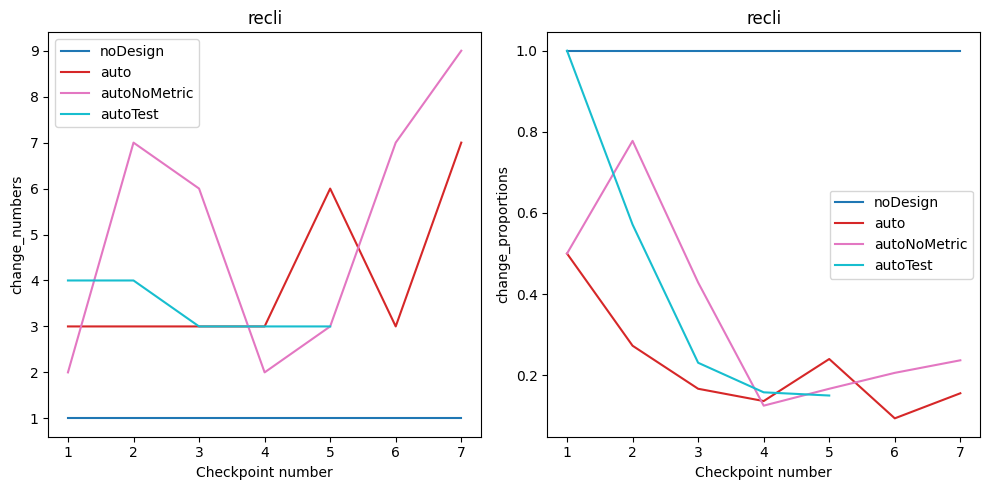

In [4]:
import os 
from metrics.change_coupling.overall_metrics import get_added_files, get_changed_files, get_deleted_files, get_all_modules, get_change_coupling

# data is in the form of [[{...}, {...}], [... ]]
data = []

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 

    checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
    checkpoint_dirs.sort() 

    data_mode = [] 
    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        changed = get_changed_files(prev_impl_dir, impl_dir)
        total = get_all_modules(prev_impl_dir)
        print(f"{prev_impl_dir}->{impl_dir}: {get_changed_files(prev_impl_dir, impl_dir)}")

        data_mode.append({
            "change_numbers": len(changed), 
            "change_proportions": len(changed) / len(total)
        })

    data.append(data_mode)

    # print the change coupling metric 
    impl_dirs = [dirs[mode_no] / x for x in checkpoint_dirs]
    print(impl_dirs)
    print('\n'.join([str(x) for x in (get_change_coupling(impl_dirs)["pairs"])]))
    print(get_change_coupling(impl_dirs)["score"])

# plot 
plot(data, ["change_numbers", "change_proportions"])


## Added and changed lines

[[{'churn': 428, 'churn_proportion': 1.3630573248407643, 'deleted_proportion': 0.0031847133757961785}, {'churn': 295, 'churn_proportion': 0.39918809201623817, 'deleted_proportion': 0.012178619756427604}, {'churn': 331, 'churn_proportion': 0.3257874015748031, 'deleted_proportion': 0.002952755905511811}, {'churn': 223, 'churn_proportion': 0.1662938105891126, 'deleted_proportion': 0.0}, {'churn': 444, 'churn_proportion': 0.28388746803069054, 'deleted_proportion': 0.0012787723785166241}, {'churn': 420, 'churn_proportion': 0.20958083832335328, 'deleted_proportion': 0.000499001996007984}, {'churn': 547, 'churn_proportion': 0.2258464079273328, 'deleted_proportion': 0.009083402146985962}], [{'churn': 815, 'churn_proportion': 1.5290806754221389, 'deleted_proportion': 0.30956848030018763}, {'churn': 920, 'churn_proportion': 0.9037328094302554, 'deleted_proportion': 0.20235756385068762}, {'churn': 695, 'churn_proportion': 0.45543905635648757, 'deleted_proportion': 0.05832241153342071}, {'churn': 

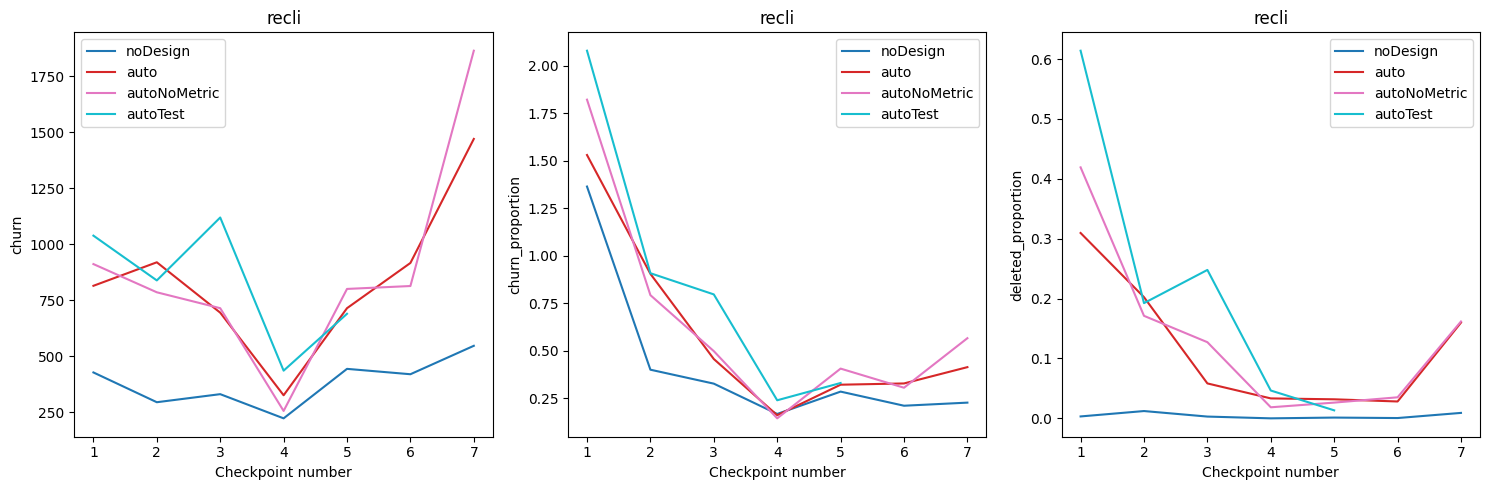

In [5]:
import os 
from metrics.change_coupling.overall_metrics import get_added_deleted_lines

# data is in the form of [[{...}, {...}], [... ]]
data = []

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 

    checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
    checkpoint_dirs.sort() 

    data_mode = [] 
    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        tmp = get_added_deleted_lines(old_dir=prev_impl_dir, new_dir=impl_dir) 
        data_mode.append({
            "churn": tmp["added"]+tmp["deleted"], 
            "churn_proportion": (tmp["added"]+tmp["deleted"]) / tmp["old_loc"] if tmp["old_loc"] > 0 else 0, 
            "deleted_proportion": (tmp["deleted"]) / tmp["old_loc"] if tmp["old_loc"] > 0 else 0, 
        })

    data.append(data_mode)

print(data)
plot(data, ["churn", "churn_proportion", "deleted_proportion"])

## Token counts (Implementation)

[[{'total': 359082, 'non_cached': 30890}, {'total': 565534, 'non_cached': 42014}, {'total': 619737, 'non_cached': 74713}, {'total': 402400, 'non_cached': 33760}, {'total': 321279, 'non_cached': 30719}, {'total': 549539, 'non_cached': 48291}, {'total': 637023, 'non_cached': 47967}, {'total': 1388629, 'non_cached': 72533}], [{'total': 558965, 'non_cached': 44405}, {'total': 642807, 'non_cached': 53495}, {'total': 899226, 'non_cached': 66458}, {'total': 498557, 'non_cached': 49789}, {'total': 464746, 'non_cached': 54378}, {'total': 642745, 'non_cached': 55225}, {'total': 920146, 'non_cached': 75090}, {'total': 1510499, 'non_cached': 82275}], [{'total': 314265, 'non_cached': 44953}, {'total': 465660, 'non_cached': 45820}, {'total': 1249654, 'non_cached': 111478}, {'total': 613946, 'non_cached': 49210}, {'total': 562786, 'non_cached': 52578}, {'total': 797392, 'non_cached': 73424}, {'total': 564763, 'non_cached': 51227}, {'total': 1595554, 'non_cached': 82338}], [{'total': 570439, 'non_cach

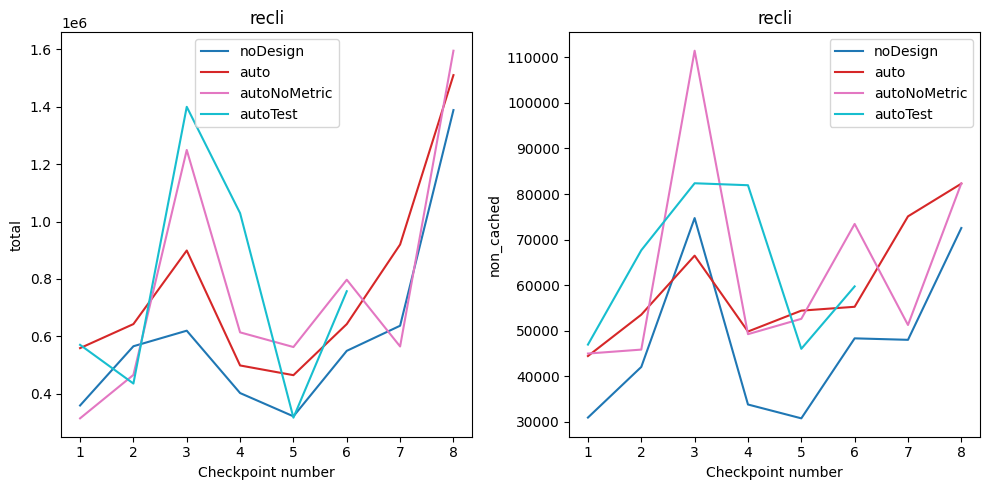

In [6]:
# Create token_data in the form of [[{total, non_cached}]]
# where non_cached = input - cached input + output tokens 
import json 
import os 

if TYPE == "custom": 
    report_dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/report_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "scb": 
    report_dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/report_{x}_{AGENT}_{MODEL}") for x in MODES
    ]

report_data = [] 
for mode_no, mode in enumerate(MODES): 
    path = report_dirs[mode_no]

    checkpoint_dirs = [] 
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    data_mode = [] 
    for checkpoint in checkpoint_dirs: 
        report_path = os.path.join(path, f"{checkpoint}.json") 

        # open each report path and get the data 
        with open(report_path, 'r') as f: 
            tokens_data = json.load(f) 

            data_mode.append({
                "total": tokens_data["tokens"]["total_tokens"], 
                "non_cached": tokens_data["tokens"]["input_tokens"] - tokens_data["tokens"]["cached_input_tokens"] + tokens_data["tokens"]["output_tokens"]
            })
    report_data.append(data_mode) 

print(report_data)

plot(report_data, ["total", "non_cached"])    


## Logical lines of code

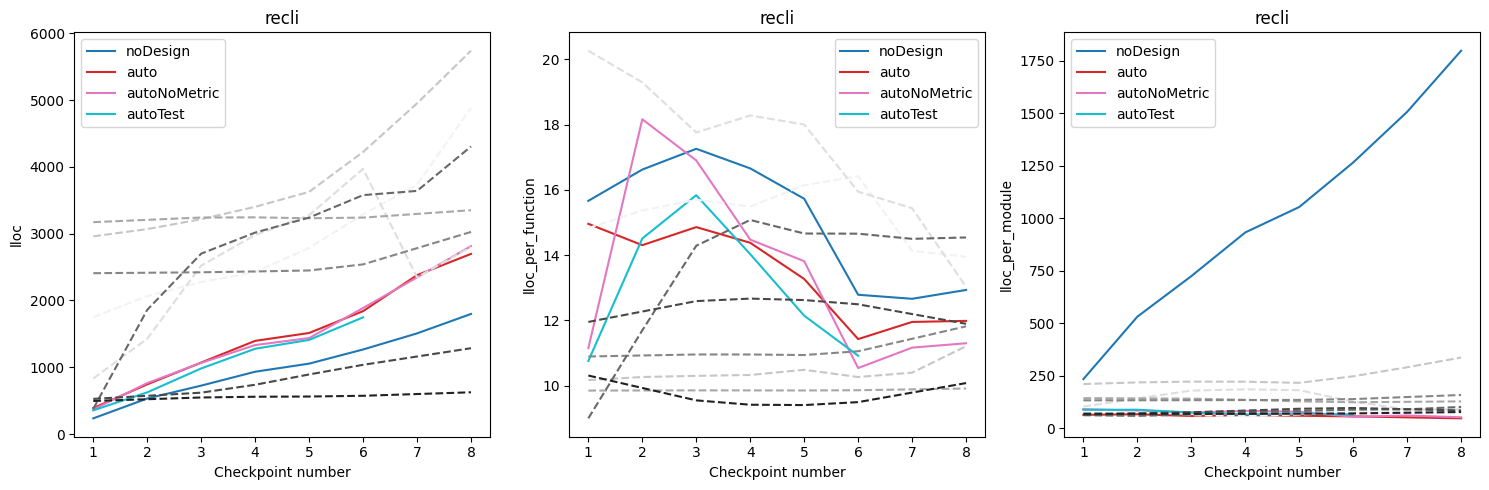

In [7]:
plot(metrics, ["lloc", "lloc_per_function", "lloc_per_module"], with_references=True)

## Functions with high CC / LOC

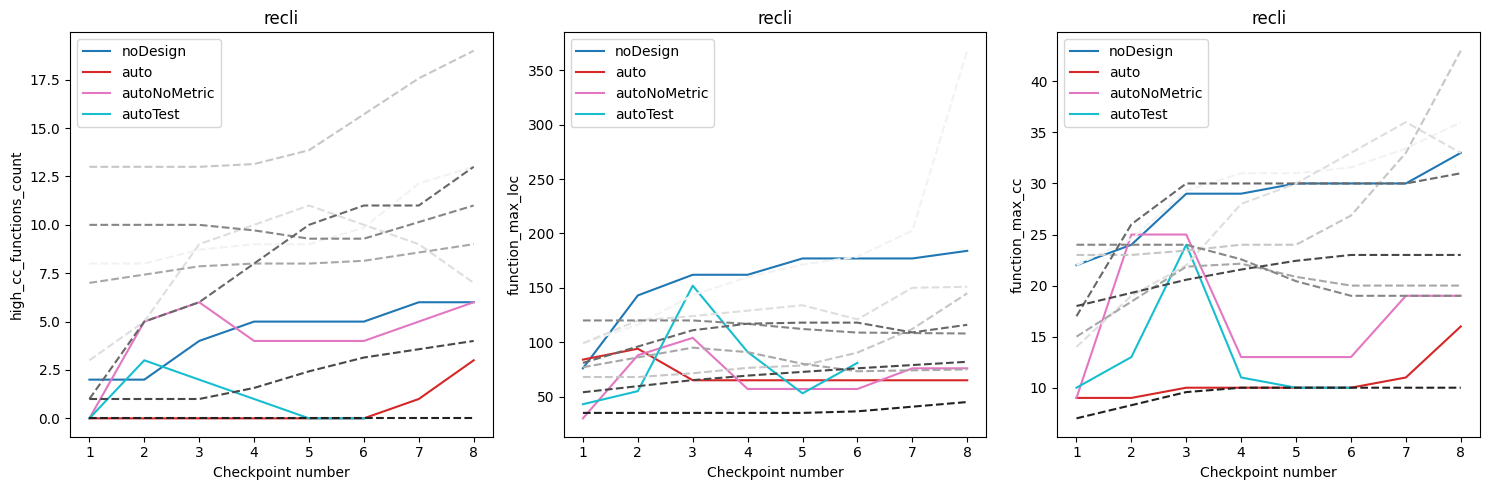

In [8]:
plot(metrics, ["high_cc_functions_count", "function_max_loc", "function_max_cc"], with_references=True)

## Maintainability index (Weighted)

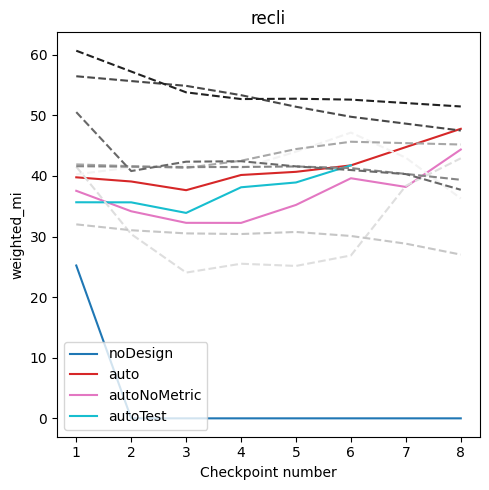

In [9]:
plot(metrics, ["weighted_mi"], with_references=True)

## Duplicated lines and tokens percentage

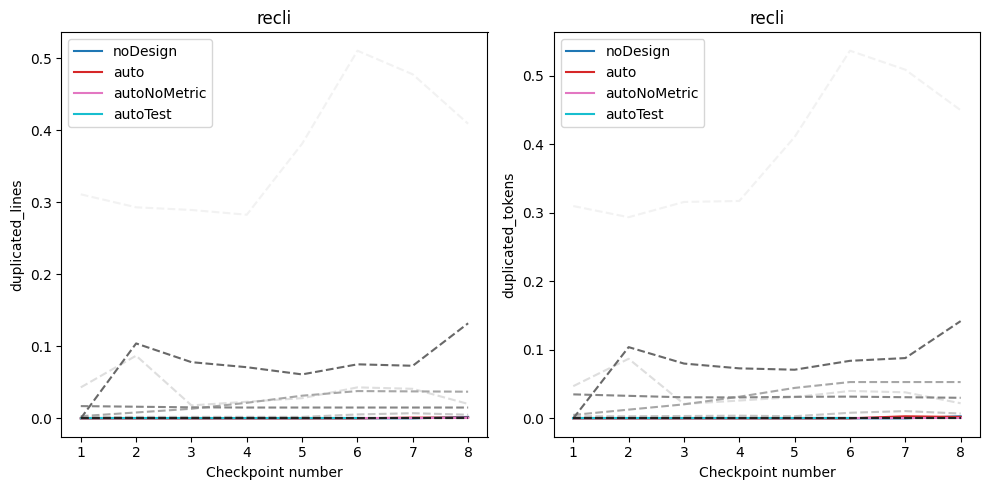

In [10]:
plot(metrics, ["duplicated_lines", "duplicated_tokens"], with_references=True)

## Whether graph has cycles

In [11]:
for i, entry in enumerate(metrics): 
    print(f"{MODES[i]}: {[x["has_cycles"] for x in entry]}")

noDesign: [False, False, False, False, False, False, False, False]
auto: [False, False, False, False, False, False, False, False]
autoNoMetric: [False, False, False, False, False, False, False, False]
autoTest: [False, False, False, False, False, False]


## Graph average degree

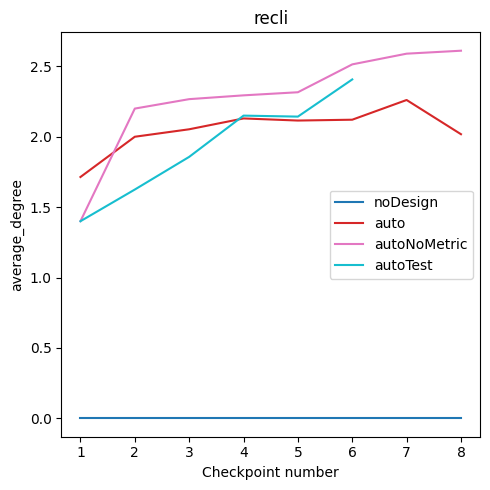

In [12]:
plot(metrics, ["average_degree"])

## NOPM per class

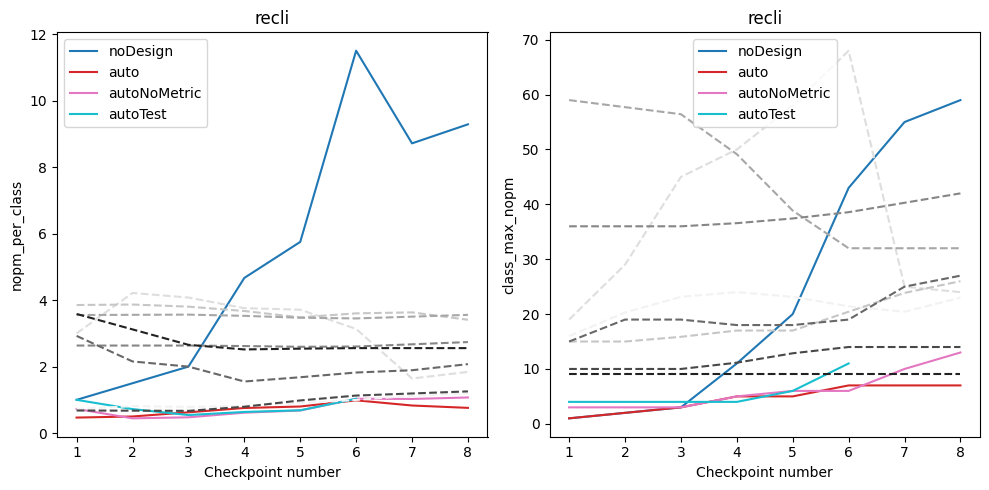

In [13]:
plot(metrics, ["nopm_per_class", "class_max_nopm"], with_references=True)

## Number of functions per module

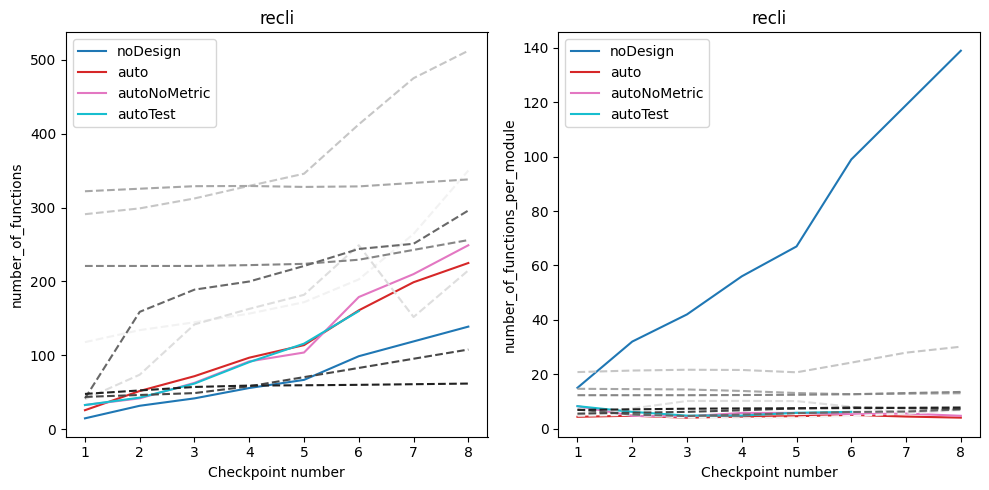

In [14]:
plot(metrics, ["number_of_functions", "number_of_functions_per_module"], with_references=True)

## Propagation cost, N and impact size

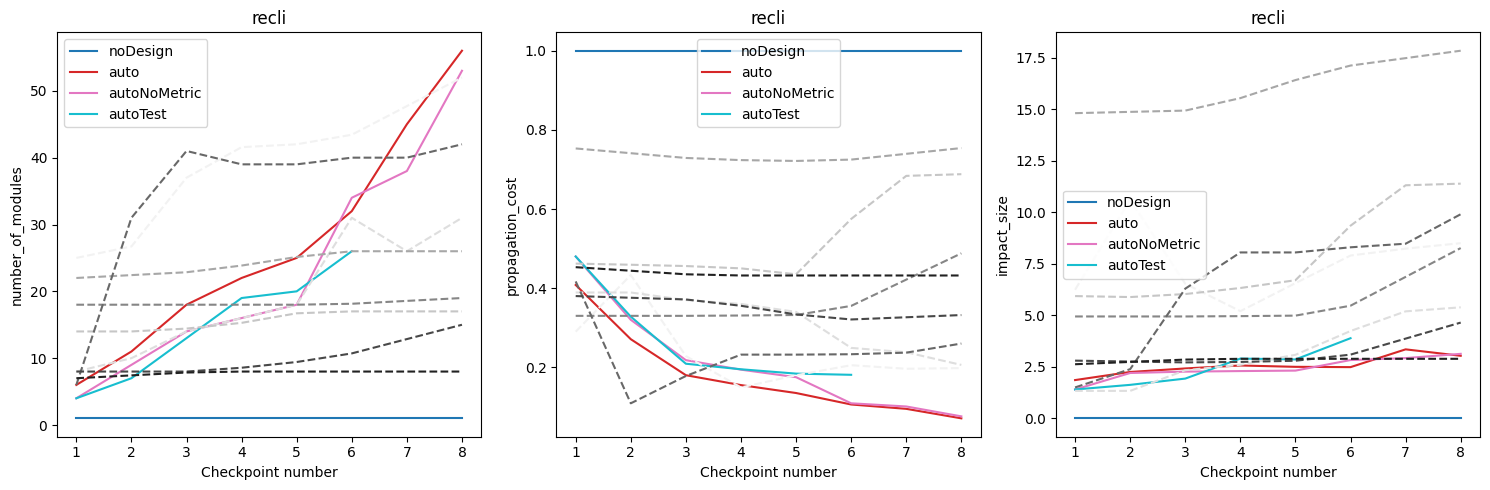

In [15]:
plot(metrics, ["number_of_modules", "propagation_cost", "impact_size"], with_references=True)

## Correctness (scb only)

In [2]:
from modular_main.entry_files import ENTRY_FILES
from scripts.pytest_scb import pytest_scb

# current tests = tests for the current checkpoint, e.g. 8 against 8 
# prev tests = test of previous checkpoints for the current impl, e.g. 8 against 7
current_tests = [] 
prev_tests = [] 
all_tests = [] 

if TYPE == "scb": 
    for mode_no, mode in enumerate(MODES): 
        # Obtain the checkpoint directories names of the problem
        # checkpoint_1, checkpoint_2, ... checkpoint_N
        checkpoint_dirs = []
        for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
            # only extract the top level iteration 
            checkpoint_dirs = dir 
            break 

        # remove directories that does not start with checkpoint_X
        checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
        checkpoint_dirs.sort() 
        N = len(checkpoint_dirs)

        current_tests_mode = [] 
        prev_tests_mode = [] 
        all_tests_mode = [] 

        # walk through each checkpoint 
        for i, checkpoint_name in enumerate(checkpoint_dirs): 
            current_checkpoint = i+1
            impl_dir = dirs[mode_no] / checkpoint_name

            # build the entrypoint path 
            entrypoint_path = Path(f"{impl_dir}/{ENTRY_FILES[PROBLEM]}.py")

            # run tests for checkpoint from N to 1 
            current_tests_ran = 0 
            current_tests_success = 0 
            prev_tests_ran = 0 
            prev_tests_success = 0 

            for cp in range(current_checkpoint, 0, -1): 
                result = pytest_scb(
                    problem_name=PROBLEM, 
                    entrypoint_path=entrypoint_path, 
                    checkpoint_number_to_test_against=cp
                )

                # append to current if it is the latest checkpoint test, else append to prev 
                if cp == current_checkpoint: 
                    current_tests_ran += result.get("total", 0)
                    current_tests_success += result.get("passed", 0)
                else: 
                    prev_tests_ran += result.get("total", 0)
                    prev_tests_success += result.get("passed", 0)

            current_tests_mode.append(current_tests_success/current_tests_ran if current_tests_ran>0 else 1)
            prev_tests_mode.append(prev_tests_success/prev_tests_ran if prev_tests_ran>0 else 1)
            all_tests_mode.append((current_tests_success + prev_tests_success)/(current_tests_ran + prev_tests_ran) if (current_tests_ran + prev_tests_ran)>0 else 1)

        current_tests.append(current_tests_mode) 
        prev_tests.append(prev_tests_mode) 
        all_tests.append(all_tests_mode) 

    print(current_tests) 
    print(prev_tests) 
    print(all_tests)    

============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-9.0.3, pluggy-1.6.0
rootdir: /home/bernardmoy/modular-SWE
plugins: respx-0.23.1, xdist-3.8.0, asyncio-1.3.0, anyio-4.13.0, json-report-1.5.0, metadata-3.1.1
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collected 13 items

datasets/slopCodeBench/scb-problems-sols-tests/code_search/tests/test_checkpoint_1.py F [  7%]
F.........F.                                                             [100%]

=================================== FAILURES ===================================
__________________________________ test_basic __________________________________

entrypoint_argv = ['python', 'datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1/code_search.py']
proj_dir = PosixPath('/home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems-so

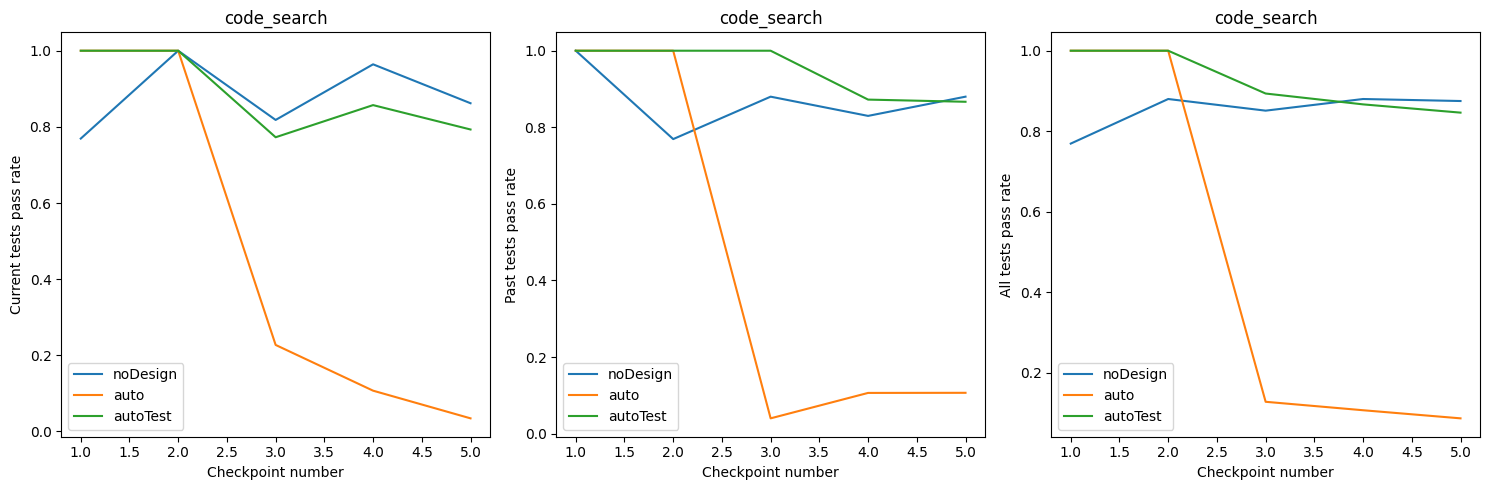

In [3]:
import matplotlib.pyplot as plt 

if TYPE == "scb": 
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

    for mode_no, mode in enumerate(MODES): 
        data = current_tests[mode_no] 
        x = range(1, len(data) + 1) 
        y = data
        ax1.plot(x, y, label=mode)
        ax1.set_xlabel("Checkpoint number")
        ax1.set_ylabel("Current tests pass rate")
        ax1.set_title(PROBLEM)
        ax1.legend()

        data = prev_tests[mode_no] 
        x = range(1, len(data) + 1) 
        y = data
        ax2.plot(x, y, label=mode)
        ax2.set_xlabel("Checkpoint number")
        ax2.set_ylabel("Past tests pass rate")
        ax2.set_title(PROBLEM)
        ax2.legend()

        data = all_tests[mode_no] 
        x = range(1, len(data) + 1) 
        y = data
        ax3.plot(x, y, label=mode)
        ax3.set_xlabel("Checkpoint number")
        ax3.set_ylabel("All tests pass rate")
        ax3.set_title(PROBLEM)
        ax3.legend()

    plt.tight_layout()
    plt.show()

## Spider diagrams (test) 

## 

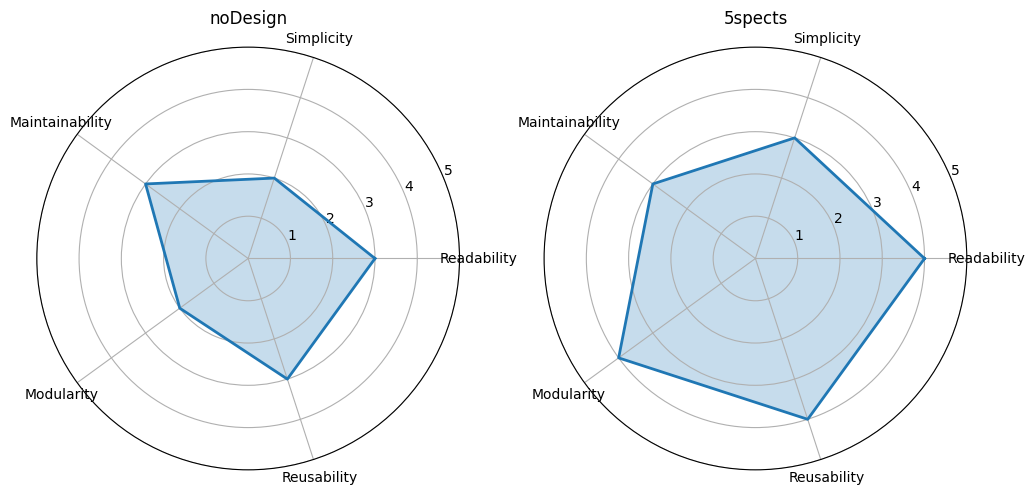

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["Readability", "Simplicity", "Maintainability", "Modularity", "Reusability"]
values_noDesign = [3,2,3,2,3]
values_5aspects = [4,3,3,4,4]

# Number of variables
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the loop

# Values also need to loop back to the first point
# (Append the first value to the end) 
values_noDesign += values_noDesign[:1]
values_5aspects += values_5aspects[:1]

# Create the plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 6), subplot_kw=dict(polar=True))

# Draw the outline and fill
ax1.plot(angles, values_noDesign, linewidth=2, linestyle='solid')
ax1.fill(angles, values_noDesign, alpha=0.25)

# Set category labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax1.set_ylim(0, 5)
ax1.set_yticks([1, 2, 3, 4, 5])

ax1.set_title("noDesign")

# Draw the outline and fill
ax2.plot(angles, values_5aspects, linewidth=2, linestyle='solid')
ax2.fill(angles, values_5aspects, alpha=0.25)

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax2.set_ylim(0, 5)
ax2.set_yticks([1, 2, 3, 4, 5])

ax2.set_title("5spects")

plt.show()